In [1]:
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
nodes = pd.read_csv(
    "/Users/yimengliu/Documents/Erdos_Institute/mgp/summer26-math-genealogy/data/processed/version2_new_dataset_fitted.csv"
)

## 0. Data Cleaning

In [3]:
codes=np.sort(nodes.subject_code.dropna().unique())
print(codes)

[ 0.  1.  3.  5.  6.  8. 11. 12. 13. 14. 15. 16. 17. 18. 19. 20. 22. 26.
 28. 30. 31. 32. 33. 34. 35. 37. 39. 40. 41. 42. 43. 44. 45. 46. 47. 49.
 51. 52. 53. 54. 55. 57. 58. 60. 62. 65. 68. 70. 74. 76. 78. 80. 81. 82.
 83. 85. 86. 90. 91. 92. 93. 94. 97.]


In [10]:
idx = np.where(codes == 14)[0][0]
print(idx)

9


In [4]:
#Take data from year between 1900 and 2024
years = np.arange(1900, 2025)

valid_pure = nodes[
    (nodes["subject_code"].notna()) &
    (nodes["subject_code"]<61) &
    (nodes["year"].between(1900, 2026))
].copy()

valid_pure["year"] = valid_pure["year"].astype(int)

codes_pure = np.sort(valid_pure["subject_code"].unique())

counts = pd.crosstab(
    valid_pure["subject_code"],
    valid_pure["year"]
).reindex(index=codes_pure, columns=years, fill_value=0)

year_totals = counts.sum(axis=0).replace(0, np.nan)

share = counts.div(year_totals, axis=1) * 100


In [5]:
import warnings
import numpy as np
import pandas as pd
import pmdarima as pm

from pmdarima import auto_arima
from statsmodels.tsa.api import SimpleExpSmoothing, Holt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

## 1. Function that fits the five models

In [42]:
def forecast_five_models(
    train,
    train_years,
    forecast_years
):
    """
    Fit five forecasting models to one training series.

    Parameters
    ----------
    train : array-like
        Values in the training period.

    train_years : array-like
        Years corresponding to the training period.

    forecast_years : array-like
        Future years to be predicted.

    Returns
    -------
    forecasts : dict
        Dictionary whose keys are model names and whose values
        are forecast arrays.
    """
    
    train = np.asarray(train, dtype=float)
    train_years = np.asarray(train_years, dtype=float)
    forecast_years = np.asarray(forecast_years, dtype=float)

    horizon = len(forecast_years)

    forecasts = {}

    # ---------------------------------------------------
    # 1. Simple exponential smoothing
    # ---------------------------------------------------
    ses_model = SimpleExpSmoothing(
        train,
        initialization_method="estimated"
    ).fit(
        smoothing_level=0.5,
        optimized=False
    )

    forecasts["Simple exponential smoothing"] = np.asarray(
        ses_model.forecast(horizon)
    )

    # ---------------------------------------------------
    # 2. Double exponential smoothing / Holt
    # ---------------------------------------------------
    # 2.1 Ordinary Holt with optimized parameters
    holt_optimized = Holt(
        train,
        damped_trend=False,
        initialization_method="estimated"
    ).fit(
        optimized=True
    )

    forecasts["Holt optimized"] = np.asarray(
        holt_optimized.forecast(horizon)
    )


    # 2.2 Damped Holt with optimized parameters
    holt_damped = Holt(
        train,
        damped_trend=True,
        initialization_method="estimated"
    ).fit(
        optimized=True
    )

    forecasts["Holt damped"] = np.asarray(
        holt_damped.forecast(horizon)
    )
    # ---------------------------------------------------
    # 3. Linear trend
    # ---------------------------------------------------
    linear_model = LinearRegression()

    linear_model.fit(
        train_years.reshape(-1, 1),
        train
    )

    forecasts["Linear trend"] = linear_model.predict(
        forecast_years.reshape(-1, 1)
    )

    # ---------------------------------------------------
    # 4. Manually specified ARIMA(0, 0, 2)
    # Create a new model object for every fit.
    # ---------------------------------------------------
    arima_002_model = pm.ARIMA(
        order=(0, 0, 2),
        with_intercept=False,
        suppress_warnings=True
    ).fit(train)

    forecasts["ARIMA(0,0,2)"] = np.asarray(
        arima_002_model.predict(n_periods=horizon)
    )

    # ---------------------------------------------------
    # 5. Auto-ARIMA
    # Restrict maximum p and q to keep cross-validation
    # computationally manageable.
    # ---------------------------------------------------
    auto_model = auto_arima(
        train,
        start_p=0,
        start_q=0,
        max_p=3,
        max_q=3,
        seasonal=False,
        stepwise=True,
        suppress_warnings=True,
        error_action="ignore",
        trace=False
    )

    forecasts["Auto ARIMA"] = np.asarray(
        auto_model.predict(n_periods=horizon)
    )

    return forecasts

## 2. Rolling window cross validation

In [64]:
def rolling_window_cv(
    y,
    year_values,
    window_size=40,
    horizon=5,
    step=5
):
    y = np.asarray(y, dtype=float)
    year_values = np.asarray(year_values)

    metric_records = []
    forecast_records = []

    fold_number = 0

    for test_start in range(
        window_size,
        len(y) - horizon + 1,
        step
    ):
        fold_number += 1

        train_start = test_start - window_size
        test_end = test_start + horizon

        train = y[train_start:test_start]
        test = y[test_start:test_end]

        train_years = year_values[train_start:test_start]
        test_years = year_values[test_start:test_end]

        forecasts = forecast_five_models(
            train=train,
            train_years=train_years,
            forecast_years=test_years
        )

        mase_scale = np.mean(np.abs(np.diff(train)))

        for model_name, prediction in forecasts.items():
            prediction = np.asarray(prediction)

            fold_mse = mean_squared_error(test, prediction)
            fold_mae = mean_absolute_error(test, prediction)

            metric_records.append({
                "fold": fold_number,
                "model": model_name,
                "train_start": train_years[0],
                "train_end": train_years[-1],
                "test_start": test_years[0],
                "test_end": test_years[-1],
                "MSE": fold_mse,
                "RMSE": np.sqrt(fold_mse),
                "MAE": fold_mae,
                "MASE": (
                    fold_mae / mase_scale
                    if mase_scale > 0
                    else np.nan
                )
            })

    return pd.DataFrame(metric_records)

In [67]:
counts_rolling_metrics = rolling_window_cv(
    y=counts_subject14.to_numpy(),
    year_values=year_values,
    window_size=40,
    horizon=5,
    step=5
)

summarize_cv_results(counts_rolling_metrics)

,mean_MSE,std_MSE,mean_RMSE,mean_MAE,mean_MASE,number_of_folds
model,,,,,,
Auto ARIMA,239.585849,441.318261,11.293520,10.086186,2.036386,17
Holt damped,247.561592,433.798221,11.346155,10.061816,1.893915,17
Holt optimized,256.364924,455.572721,11.513539,10.301705,1.950997,17
Simple exponential smoothing,281.584451,639.510052,11.803194,10.378563,2.082015,17
Linear trend,347.471699,628.023144,13.850465,12.468670,2.455464,17
"ARIMA(0,0,2)",4789.261874,7602.019859,47.989807,45.389265,7.535565,17


In [66]:
share_rolling_metrics = rolling_window_cv(
    y=share_subject14.to_numpy(),
    year_values=year_values,
    window_size=40,
    horizon=5,
    step=5
)

summarize_cv_results(share_rolling_metrics)

,mean_MSE,std_MSE,mean_RMSE,mean_MAE,mean_MASE,number_of_folds
model,,,,,,
Simple exponential smoothing,2.916242,5.233893,1.315016,1.142408,0.678333,17
Holt optimized,2.996028,5.399155,1.364355,1.182485,0.675882,17
Linear trend,3.098500,3.435763,1.496098,1.342957,0.770644,17
Holt damped,3.785425,8.275471,1.427135,1.257610,0.682527,17
Auto ARIMA,7.478432,16.357815,1.889330,1.722592,0.739154,17
"ARIMA(0,0,2)",17.888758,12.946797,4.002245,3.721351,3.744273,17


## 3. Summary for cross validation (from expanding window)

In [47]:
def summarize_cv_results(cv_metrics):
    """
    Summarize forecasting performance across all folds.
    """

    summary = (
        cv_metrics
        .groupby("model")
        .agg(
            mean_MSE=("MSE", "mean"),
            std_MSE=("MSE", "std"),
            mean_RMSE=("RMSE", "mean"),
            mean_MAE=("MAE", "mean"),
            mean_MASE=("MASE", "mean"),
            number_of_folds=("fold", "nunique")
        )
        .sort_values("mean_MSE")
    )

    return summary

In [48]:
counts_cv_summary = summarize_cv_results(counts_cv_metrics)
counts_cv_summary

,mean_MSE,std_MSE,mean_RMSE,mean_MAE,mean_MASE,number_of_folds
model,,,,,,
Holt damped,429.039138,518.288352,17.073363,15.309792,3.661040,9
Holt optimized,434.767321,537.191420,17.099446,15.345915,3.655965,9
Simple exponential smoothing,508.414227,833.092828,18.377347,16.316975,4.201163,9
Auto ARIMA,538.614427,646.929667,19.346587,17.242137,4.136153,9
Linear trend,3071.030038,3092.184024,48.201362,47.101610,11.439340,9
"ARIMA(0,0,2)",9205.873236,8955.376700,83.856746,80.155706,19.340443,9


In [49]:
share_cv_summary = summarize_cv_results(share_cv_metrics)
share_cv_summary

,mean_MSE,std_MSE,mean_RMSE,mean_MAE,mean_MASE,number_of_folds
model,,,,,,
Simple exponential smoothing,0.881462,0.801891,0.836060,0.721958,0.193662,9
Holt damped,1.126646,0.996894,0.964543,0.826908,0.221884,9
Auto ARIMA,3.678880,4.685762,1.585518,1.446902,0.363901,9
Holt optimized,9.337414,11.290720,2.657547,2.570398,0.643997,9
"ARIMA(0,0,2)",27.603748,14.910010,5.102757,4.954207,1.334094,9
Linear trend,31.426970,5.371601,5.589513,5.551340,1.465532,9


### 3.1 View the error from each fold

In [50]:
share_cv_metrics.pivot(
    index="fold",
    columns="model",
    values="MSE"
)

model,"ARIMA(0,0,2)",Auto ARIMA,Holt damped,Holt optimized,Linear trend,Simple exponential smoothing
fold,,,,,,
1,13.662991,12.403337,1.882922,28.665838,28.665769,1.790327
2,14.888040,10.951990,0.468174,29.498300,29.498285,0.087878
3,14.378691,0.229913,0.113063,3.297500,26.088411,0.071539
4,22.990371,1.674739,1.483084,5.548179,32.548363,1.539751
5,25.526058,1.616059,0.957887,3.938028,32.794385,0.537279
6,24.804639,0.108202,0.146077,1.313363,26.681327,0.223860
7,33.333181,1.049766,0.920030,3.080972,31.441259,0.867906
8,38.725665,1.088119,0.875237,2.548683,30.852351,0.542733
9,60.124090,3.987792,3.293336,6.145864,44.272580,2.271886


## 4. Plot cross-validation predictions

In [61]:
import matplotlib.pyplot as plt


def plot_cv_forecasts(
    original_series,
    year_values,
    cv_forecasts,
    model_name,
    title
):
    plt.figure(figsize=(16, 7))

    plt.plot(
        year_values,
        original_series,
        label="Actual series",
        linewidth=2
    )

    selected = cv_forecasts[
        cv_forecasts["model"] == model_name
    ]

    for fold in selected["fold"].unique():
        fold_data = selected[selected["fold"] == fold]

        plt.plot(
            fold_data["year"],
            fold_data["predicted"],
            marker="o",
            linestyle="--",
            alpha=0.8
        )

    plt.xlabel("Year")
    plt.ylabel("Value")
    plt.title(title)
    plt.legend()
    plt.show()

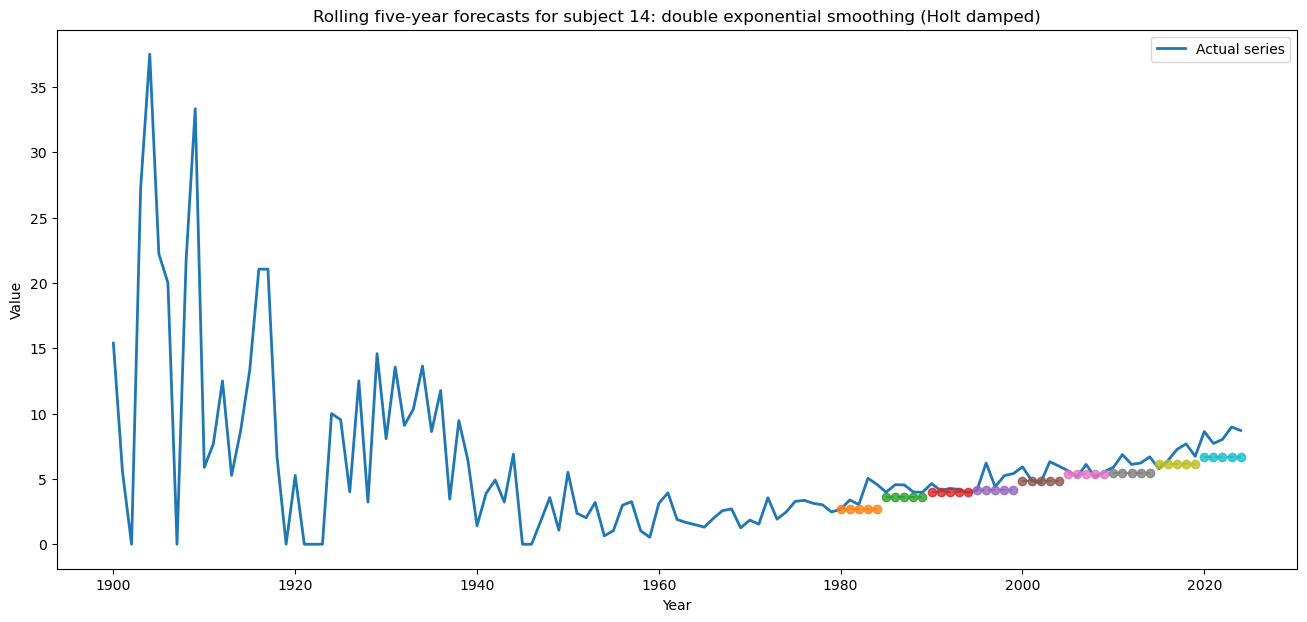

In [63]:
plot_cv_forecasts(
    original_series=share_subject14.to_numpy(),
    year_values=year_values,
    cv_forecasts=share_cv_forecasts,
    model_name="Holt damped",
    title=(
        "Rolling five-year forecasts for subject 14: "
        "double exponential smoothing (Holt damped)"
    )
)

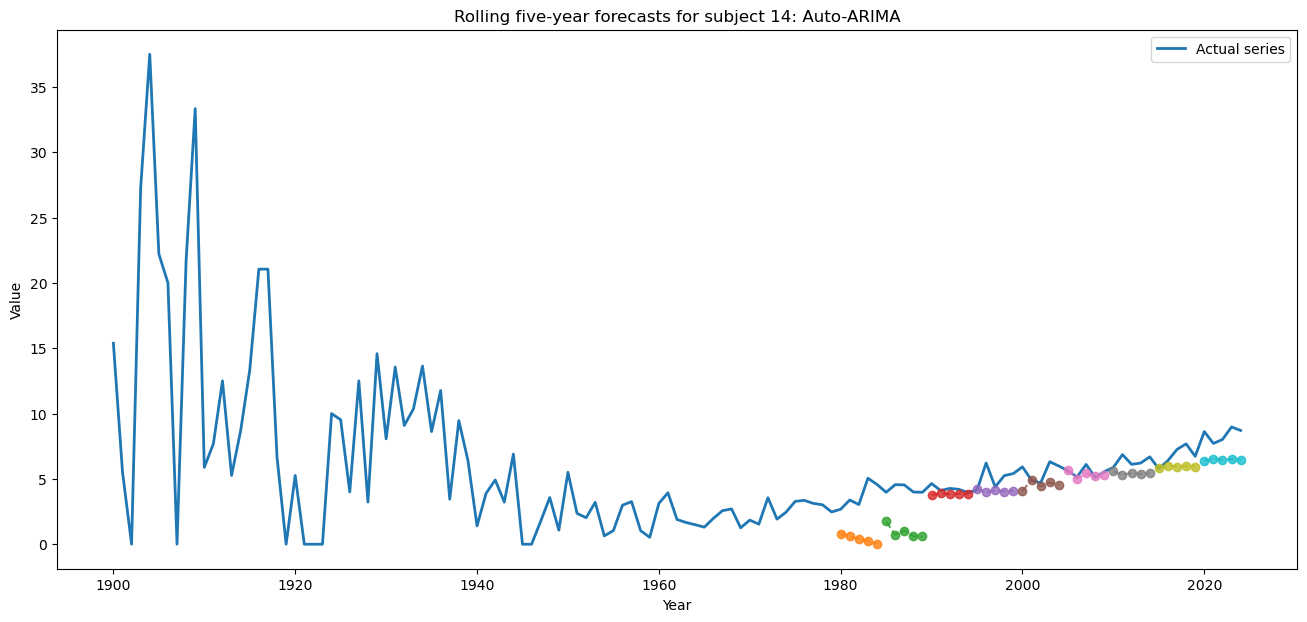

In [21]:
plot_cv_forecasts(
    original_series=share_subject14.to_numpy(),
    year_values=year_values,
    cv_forecasts=share_cv_forecasts,
    model_name="Auto ARIMA",
    title=(
        "Rolling five-year forecasts for subject 14: "
        "Auto-ARIMA"
    )
)

## 5. one year versus five years

In [ ]:
counts_cv_1year, counts_forecasts_1year = rolling_window_cv(
    y=counts_subject14.to_numpy(),
    year_values=year_values,
    window_size=40,
    horizon=1,
    step=1
)

summarize_cv_results(counts_cv_1year)

In [68]:
share_cv_1year, share_forecasts_1year = expanding_window_cv(
    y=share_subject14.to_numpy(),
    year_values=year_values,
    initial_train_size=80,
    horizon=1,
    step=1
)

summarize_cv_results(share_cv_1year)

,mean_MSE,std_MSE,mean_RMSE,mean_MAE,mean_MASE,number_of_folds
model,,,,,,
Simple exponential smoothing,0.535264,0.961919,0.548667,0.548667,0.147849,45
Holt damped,0.736463,1.143998,0.643792,0.643792,0.174824,45
Auto ARIMA,1.771140,3.067026,0.956101,0.956101,0.247567,45
Holt optimized,4.731993,6.919144,1.780360,1.780360,0.454385,45
"ARIMA(0,0,2)",9.100141,6.292885,2.846169,2.846169,0.777781,45
Linear trend,26.938609,7.494218,5.143002,5.143002,1.381107,45


In [ ]:
share_cv_1year = rolling_window_cv(
    y=share_subject14.to_numpy(),
    year_values=year_values,
    window_size=40,
    horizon=1,
    step=1
)

summarize_cv_results(share_cv_1year)

ValueError: too many values to unpack (expected 2)

## 6. All subjects

In [ ]:
def cross_validate_all_subjects(
    matrix,
    train_size=80,
    horizon=5,
    step=5
):
    """
    Run expanding-window CV on every row of a subject matrix.
    """

    all_results = []

    year_values = matrix.columns.to_numpy(dtype=int)

    for row_position in range(matrix.shape[0]):

        subject_code = matrix.index[row_position]
        y = matrix.iloc[row_position].astype(float)

        print(
            f"Processing row {row_position}, "
            f"subject code {subject_code}"
        )

        try:
            metrics, _ = rolling_window_cv(
                y=y.to_numpy(),
                year_values=year_values,
                train_size=train_size,
                horizon=horizon,
                step=step
            )

            metrics["row_position"] = row_position
            metrics["subject_code"] = subject_code

            all_results.append(metrics)

        except Exception as error:
            print(
                f"Subject code {subject_code} failed: {error}"
            )

    if not all_results:
        return pd.DataFrame()

    return pd.concat(
        all_results,
        ignore_index=True
    )

In [72]:
all_share_cv_results = cross_validate_all_subjects(
    matrix=share,
    initial_train_size=80,
    horizon=5,
    step=5
)

Processing row 0, subject code 0.0
Processing row 1, subject code 1.0
Processing row 2, subject code 3.0
Processing row 3, subject code 5.0
Processing row 4, subject code 6.0
Processing row 5, subject code 8.0
Processing row 6, subject code 11.0
Processing row 7, subject code 12.0
Processing row 8, subject code 13.0
Processing row 9, subject code 14.0
Processing row 10, subject code 15.0
Processing row 11, subject code 16.0
Processing row 12, subject code 17.0
Processing row 13, subject code 18.0
Processing row 14, subject code 19.0
Processing row 15, subject code 20.0
Processing row 16, subject code 22.0
Processing row 17, subject code 26.0
Processing row 18, subject code 28.0
Processing row 19, subject code 30.0
Processing row 20, subject code 31.0
Processing row 21, subject code 32.0
Processing row 22, subject code 33.0
Processing row 23, subject code 34.0
Processing row 24, subject code 35.0
Processing row 25, subject code 37.0
Processing row 26, subject code 39.0
Processing row 27

In [73]:
subject_model_summary = (
    all_share_cv_results
    .groupby(
        [
            "row_position",
            "subject_code",
            "model"
        ]
    )
    .agg(
        mean_MSE=("MSE", "mean"),
        mean_RMSE=("RMSE", "mean"),
        mean_MAE=("MAE", "mean"),
        mean_MASE=("MASE", "mean"),
        number_of_folds=("fold", "nunique")
    )
    .reset_index()
)

subject_model_summary.head()

,row_position,subject_code,model,mean_MSE,mean_RMSE,mean_MAE,mean_MASE,number_of_folds
0,0,0.0,"ARIMA(0,0,2)",1.313566,1.100758,1.064876,1.320570,9
1,0,0.0,Auto ARIMA,0.311854,0.507080,0.460115,0.570034,9
2,0,0.0,Holt damped,0.396451,0.576848,0.530510,0.656543,9
3,0,0.0,Holt optimized,0.472893,0.637565,0.588196,0.715874,9
4,0,0.0,Linear trend,0.472892,0.637564,0.588196,0.715873,9


In [74]:
best_model_by_subject = (
    subject_model_summary
    .sort_values(
        [
            "subject_code",
            "mean_MSE"
        ]
    )
    .groupby("subject_code")
    .first()
    .reset_index()
)

best_model_by_subject

,subject_code,row_position,model,mean_MSE,mean_RMSE,mean_MAE,mean_MASE,number_of_folds
0,0.0,0,Simple exponential smoothing,0.140409,0.353513,0.295558,0.363431,9
1,1.0,1,Simple exponential smoothing,0.044091,0.197862,0.176574,0.057850,9
2,3.0,2,Simple exponential smoothing,0.534288,0.664253,0.570640,0.228475,9
3,5.0,3,Holt damped,0.542760,0.660386,0.562813,0.506500,9
4,6.0,4,Simple exponential smoothing,0.084839,0.257558,0.219852,0.247245,9
5,8.0,5,Auto ARIMA,0.039034,0.185218,0.160528,0.365571,9
6,11.0,6,Simple exponential smoothing,0.700895,0.804607,0.676233,0.173999,9
7,12.0,7,Simple exponential smoothing,0.017224,0.128353,0.107563,0.283045,9
8,13.0,8,Linear trend,0.102117,0.285853,0.252125,0.489414,9
9,14.0,9,Simple exponential smoothing,0.881462,0.836060,0.721958,0.193662,9


In [75]:
all_counts_cv_results = cross_validate_all_subjects(
    matrix=share,
    initial_train_size=40,
    horizon=5,
    step=5
)

Processing row 0, subject code 0.0
Processing row 1, subject code 1.0
Processing row 2, subject code 3.0
Processing row 3, subject code 5.0
Processing row 4, subject code 6.0
Processing row 5, subject code 8.0
Processing row 6, subject code 11.0
Processing row 7, subject code 12.0
Processing row 8, subject code 13.0
Processing row 9, subject code 14.0
Processing row 10, subject code 15.0
Processing row 11, subject code 16.0
Processing row 12, subject code 17.0
Processing row 13, subject code 18.0
Processing row 14, subject code 19.0
Processing row 15, subject code 20.0
Processing row 16, subject code 22.0
Processing row 17, subject code 26.0
Processing row 18, subject code 28.0
Processing row 19, subject code 30.0
Processing row 20, subject code 31.0
Processing row 21, subject code 32.0
Processing row 22, subject code 33.0
Processing row 23, subject code 34.0
Processing row 24, subject code 35.0
Processing row 25, subject code 37.0
Processing row 26, subject code 39.0
Processing row 27

In [76]:
subject_model_summary = (
    all_counts_cv_results
    .groupby(
        [
            "row_position",
            "subject_code",
            "model"
        ]
    )
    .agg(
        mean_MSE=("MSE", "mean"),
        mean_RMSE=("RMSE", "mean"),
        mean_MAE=("MAE", "mean"),
        mean_MASE=("MASE", "mean"),
        number_of_folds=("fold", "nunique")
    )
    .reset_index()
)

subject_model_summary.head()

,row_position,subject_code,model,mean_MSE,mean_RMSE,mean_MAE,mean_MASE,number_of_folds
0,0,0.0,"ARIMA(0,0,2)",0.989488,0.917919,0.809420,0.901635,17
1,0,0.0,Auto ARIMA,0.372714,0.546144,0.493372,0.501556,17
2,0,0.0,Holt damped,0.385848,0.545161,0.486941,0.509954,17
3,0,0.0,Holt optimized,0.471796,0.596350,0.499922,0.529370,17
4,0,0.0,Linear trend,0.471795,0.596350,0.499922,0.529370,17


In [77]:
best_model_by_subject = (
    subject_model_summary
    .sort_values(
        [
            "subject_code",
            "mean_MSE"
        ]
    )
    .groupby("subject_code")
    .first()
    .reset_index()
)

best_model_by_subject

,subject_code,row_position,model,mean_MSE,mean_RMSE,mean_MAE,mean_MASE,number_of_folds
0,0.0,0,Simple exponential smoothing,0.293591,0.444263,0.335531,0.333080,17
1,1.0,1,Simple exponential smoothing,2.074507,0.782900,0.674778,0.135061,17
2,3.0,2,Simple exponential smoothing,3.848486,1.400324,1.130109,0.354115,17
3,5.0,3,Simple exponential smoothing,0.824660,0.844144,0.722622,0.590993,17
4,6.0,4,Holt damped,0.528753,0.579157,0.513209,0.489699,17
5,8.0,5,Holt damped,0.198710,0.375762,0.326559,0.742075,17
6,11.0,6,Simple exponential smoothing,3.038632,1.342872,1.177750,0.219884,17
7,12.0,7,Simple exponential smoothing,0.040577,0.167072,0.129959,0.303460,17
8,13.0,8,Linear trend,0.477719,0.551601,0.461132,0.840074,17
9,14.0,9,Holt damped,2.868251,1.345224,1.163881,0.226147,17
